# Eval qualité: original vs compressé

Objectif : mesurer objectivement la perte de qualité induite par la compression.

Métriques utilisées :
- **SSIM** (Structural Similarity Index) : perception structurale, de 0 à 1
- **PSNR** (Peak Signal-to-Noise Ratio) : rapport signal/bruit, en dB

On compare : original SVS vs classique (notebook 2) vs adaptatif (notebook 3).

In [2]:
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import openslide
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

DATA_DIR = Path("/Users/nath/Desktop/data_stage")
OUT_DIR = Path("./expe_debut_stage")
OUT_DIR.mkdir(exist_ok=True)

svs_files = sorted(DATA_DIR.glob("*.svs"), key=lambda p: p.stat().st_size)
SVS_PATH = svs_files[50]
print("Fichier analysé :", SVS_PATH.name)

Fichier analysé : TCGA-CD-A486-01Z-00-DX1.6FFE81CA-9074-44BC-B619-85A73BA61A2D.svs


## 1. Préparation : extraire une région de tissu depuis l'original

On prend une zone de 1024×1024 au centre de la lame (probablement du tissu).

Région extraite : (1024, 1024, 3) au centre (33283, 43581)


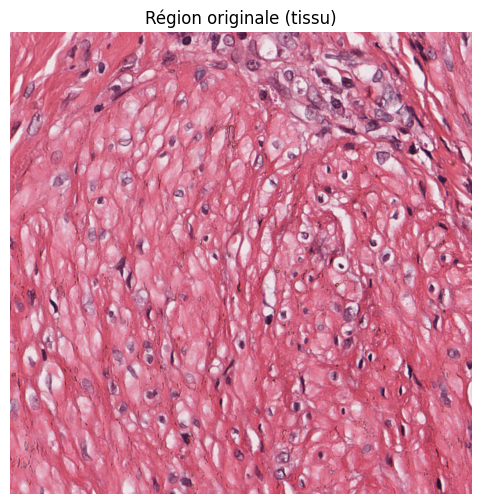

In [3]:
slide_orig = openslide.OpenSlide(str(SVS_PATH))
w0, h0 = slide_orig.level_dimensions[0]

REGION_SIZE = 1024
cx = w0 // 2 - REGION_SIZE // 2
cy = h0 // 2 - REGION_SIZE // 2

region_orig = slide_orig.read_region((cx, cy), 0, (REGION_SIZE, REGION_SIZE)).convert("RGB")
orig_arr = np.array(region_orig).astype(np.float32) / 255.0

print(f"Région extraite : {orig_arr.shape} au centre ({cx}, {cy})")
plt.figure(figsize=(6, 6))
plt.imshow(region_orig)
plt.title("Région originale (tissu)")
plt.axis("off")
plt.show()

## 2. Fonction d'évaluation d'un fichier compressé

On charge le fichier compressé, on extrait la même région, on calcule SSIM et PSNR.

In [4]:
def evaluer_fichier(path: Path, label: str):
    """Évalue la qualité d'un fichier compressé vs l'original."""
    if not path.exists():
        print(f"[SKIP] {label} : fichier non trouvé ({path.name})")
        return None
    
    slide = openslide.OpenSlide(str(path))
    region = slide.read_region((cx, cy), 0, (REGION_SIZE, REGION_SIZE)).convert("RGB")
    slide.close()
    
    rec_arr = np.array(region).astype(np.float32) / 255.0
    
    s = ssim(orig_arr, rec_arr, channel_axis=2, data_range=1.0)
    p = psnr(orig_arr, rec_arr, data_range=1.0)
    
    print(f"{label:20s} | SSIM={s:.4f} | PSNR={p:.2f} dB")
    
    return {
        "methode": label,
        "ssim": round(s, 4),
        "psnr_db": round(p, 2),
        "path": path
    }

## 3. Évaluation des fichiers compressés (notebook 2 et 3)

In [5]:
results = []

# Original (ref)
results.append({
    "methode": "ORIGINAL",
    "ssim": 1.0000,
    "psnr_db": 999.99,
    "path": SVS_PATH
})

# compression classique (notebook 2)
for q in [90, 80, 70, 60, 50]:
    p = OUT_DIR / f"{SVS_PATH.stem}_jpeg_q{q}.tiff"
    r = evaluer_fichier(p, f"CLASSIQUE Q={q}")
    if r:
        results.append(r)

# compression adaptative (notebook 3)
for q in [90, 80, 70, 60, 50]:
    p = OUT_DIR / f"{SVS_PATH.stem}_adaptive_q{q}.tiff"
    r = evaluer_fichier(p, f"ADAPTIF Q={q}")
    if r:
        results.append(r)

CLASSIQUE Q=90       | SSIM=0.9995 | PSNR=55.68 dB
CLASSIQUE Q=80       | SSIM=0.9145 | PSNR=32.31 dB
CLASSIQUE Q=70       | SSIM=0.9057 | PSNR=31.71 dB
CLASSIQUE Q=60       | SSIM=0.9031 | PSNR=31.44 dB
CLASSIQUE Q=50       | SSIM=0.8954 | PSNR=31.01 dB
ADAPTIF Q=90         | SSIM=0.9995 | PSNR=55.68 dB
ADAPTIF Q=80         | SSIM=0.9145 | PSNR=32.31 dB
ADAPTIF Q=70         | SSIM=0.9057 | PSNR=31.71 dB
ADAPTIF Q=60         | SSIM=0.9031 | PSNR=31.44 dB
ADAPTIF Q=50         | SSIM=0.8954 | PSNR=31.01 dB


## 4. Tableau récapitulatif

In [6]:
df = pd.DataFrame(results)
# On ajoute la taille si le fichier existe
df["taille_Mo"] = df["path"].apply(lambda p: round(p.stat().st_size/(1024*1024), 1) if p.exists() else None)
display(df[["methode", "taille_Mo", "ssim", "psnr_db"]])

,methode,taille_Mo,ssim,psnr_db
0,ORIGINAL,857.5,1.0000,999.99
1,CLASSIQUE Q=90,2546.7,0.9995,55.68
2,CLASSIQUE Q=80,771.0,0.9145,32.31
3,CLASSIQUE Q=70,646.6,0.9057,31.71
4,CLASSIQUE Q=60,571.5,0.9031,31.44
5,CLASSIQUE Q=50,516.5,0.8954,31.01
6,ADAPTIF Q=90,2369.0,0.9995,55.68
7,ADAPTIF Q=80,730.3,0.9145,32.31
8,ADAPTIF Q=70,617.0,0.9057,31.71
9,ADAPTIF Q=60,547.4,0.9031,31.44


## 5. Graphique SSIM vs qualité

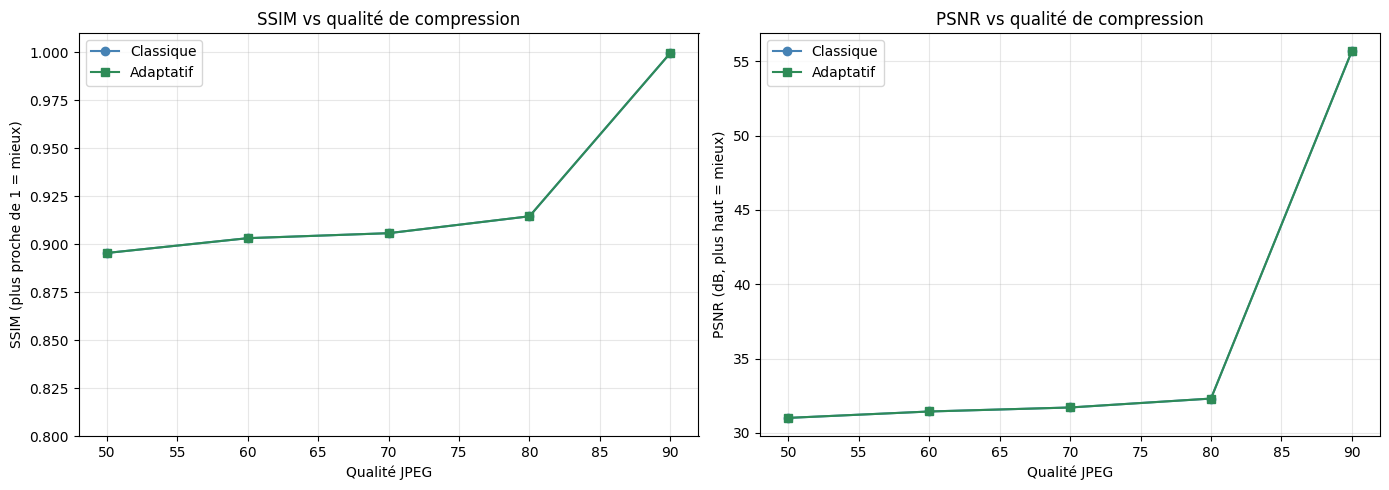

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

classic = df[df["methode"].str.startswith("CLASSIQUE")]
adaptif = df[df["methode"].str.startswith("ADAPTIF")]

# SSIM
axes[0].plot(classic["methode"].str.extract(r"Q=(\d+)").astype(int), classic["ssim"], "o-", label="Classique", color="steelblue")
axes[0].plot(adaptif["methode"].str.extract(r"Q=(\d+)").astype(int), adaptif["ssim"], "s-", label="Adaptatif", color="seagreen")
axes[0].set_xlabel("Qualité JPEG")
axes[0].set_ylabel("SSIM (plus proche de 1 = mieux)")
axes[0].set_title("SSIM vs qualité de compression")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0.8, 1.01)

# PSNR
axes[1].plot(classic["methode"].str.extract(r"Q=(\d+)").astype(int), classic["psnr_db"], "o-", label="Classique", color="steelblue")
axes[1].plot(adaptif["methode"].str.extract(r"Q=(\d+)").astype(int), adaptif["psnr_db"], "s-", label="Adaptatif", color="seagreen")
axes[1].set_xlabel("Qualité JPEG")
axes[1].set_ylabel("PSNR (dB, plus haut = mieux)")
axes[1].set_title("PSNR vs qualité de compression")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Comparaison visuelle côte à côte

On affiche la région originale à côté des versions compressées à Q=70 et Q=50 (les plus intéressantes).

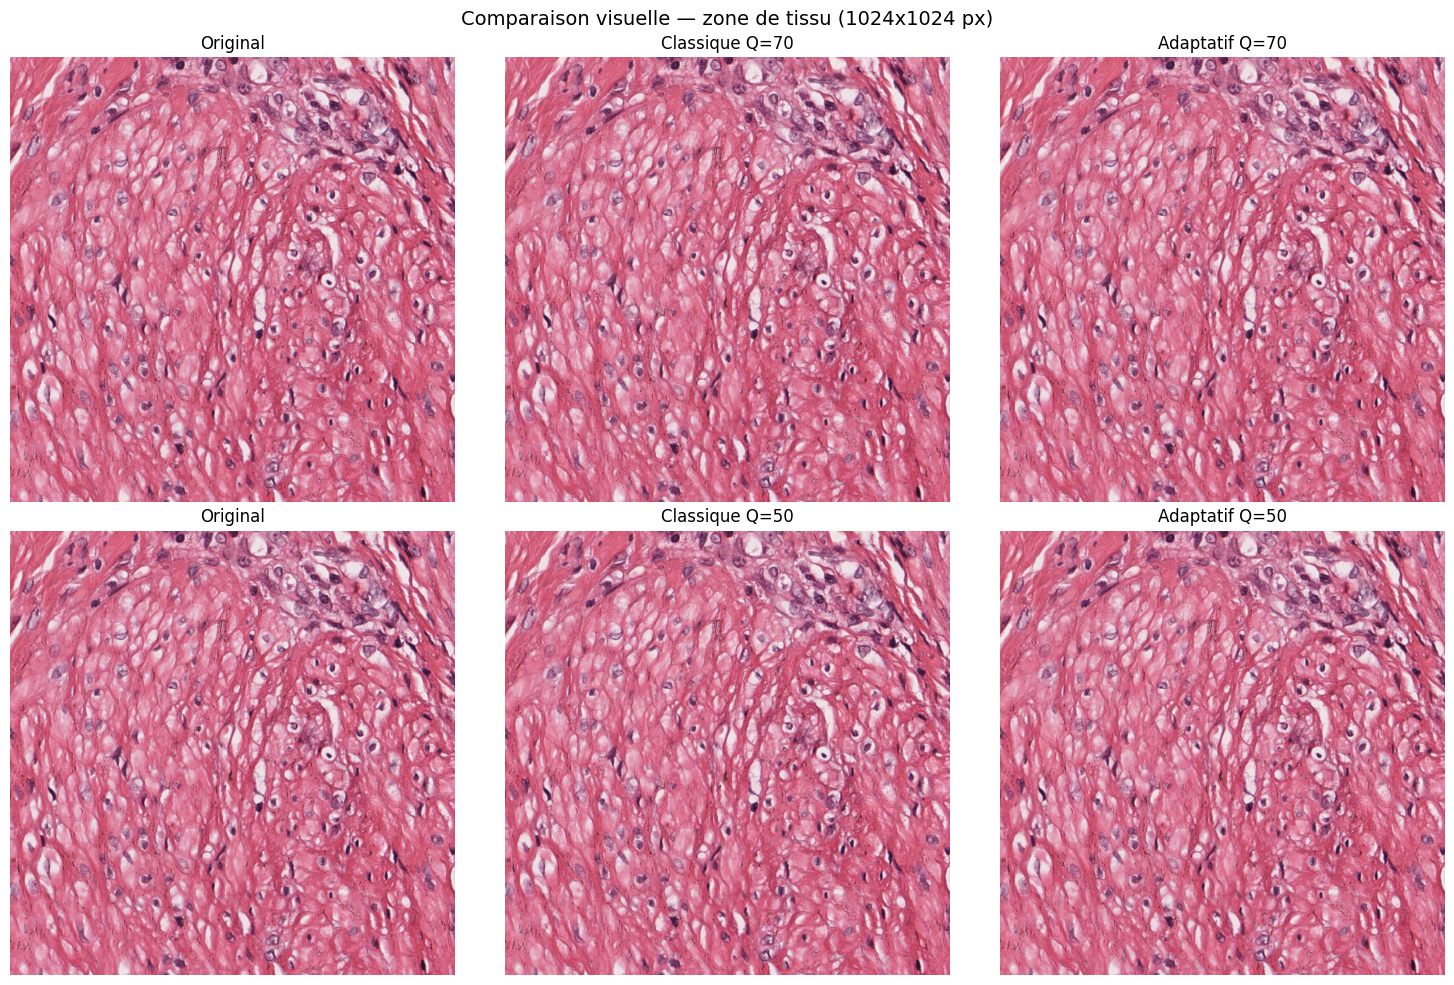

In [8]:
def charger_region(path):
    slide = openslide.OpenSlide(str(path))
    region = slide.read_region((cx, cy), 0, (REGION_SIZE, REGION_SIZE)).convert("RGB")
    slide.close()
    return region

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Ligne 1 : Q=70
axes[0, 0].imshow(region_orig)
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")

p_classic_70 = OUT_DIR / f"{SVS_PATH.stem}_jpeg_q70.tiff"
if p_classic_70.exists():
    axes[0, 1].imshow(charger_region(p_classic_70))
    axes[0, 1].set_title("Classique Q=70")
    axes[0, 1].axis("off")

p_adapt_70 = OUT_DIR / f"{SVS_PATH.stem}_adaptive_q70.tiff"
if p_adapt_70.exists():
    axes[0, 2].imshow(charger_region(p_adapt_70))
    axes[0, 2].set_title("Adaptatif Q=70")
    axes[0, 2].axis("off")

# Ligne 2 : Q=50
axes[1, 0].imshow(region_orig)
axes[1, 0].set_title("Original")
axes[1, 0].axis("off")

p_classic_50 = OUT_DIR / f"{SVS_PATH.stem}_jpeg_q50.tiff"
if p_classic_50.exists():
    axes[1, 1].imshow(charger_region(p_classic_50))
    axes[1, 1].set_title("Classique Q=50")
    axes[1, 1].axis("off")

p_adapt_50 = OUT_DIR / f"{SVS_PATH.stem}_adaptive_q50.tiff"
if p_adapt_50.exists():
    axes[1, 2].imshow(charger_region(p_adapt_50))
    axes[1, 2].set_title("Adaptatif Q=50")
    axes[1, 2].axis("off")

plt.suptitle(f"Comparaison visuelle — zone de tissu ({REGION_SIZE}x{REGION_SIZE} px)", fontsize=14)
plt.tight_layout()
plt.show()

## 7. Fermeture

In [9]:
slide_orig.close()

Ce sont de bon resultat car on a exactement les memes score ssim et psnr pour les compressions adaptatives et les compression classique alors que les compressions adaptative sont plus légères.